Basit Doğrusal Regresyon ile Tahmin




In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('../resources/factory_quality_regression.csv')

print(df.head(3))

   machine_id line  runtime_hours  sensor_alert_score  uptime_rate  \
0           1    A              6                58.0         72.0   
1           2    A              8                65.0         80.0   
2           3    A              4                49.0         66.0   

   maintenance_hours  cycle_count  quality_score  
0                6.4       5200.0             62  
1                6.8       6100.0             68  
2                5.9       4300.0             55  


In [6]:
df.isnull().sum()

machine_id            0
line                  0
runtime_hours         0
sensor_alert_score    0
uptime_rate           0
maintenance_hours     0
cycle_count           0
quality_score         0
dtype: int64

In [5]:
numeric_colums = [
    "sensor_alert_score",
    "quality_score",
    'uptime_rate',
    'maintenance_hours',
    'cycle_count',
    'runtime_hours'
]

for col in numeric_colums:
    df[col] = df[col].fillna(df[col].median())



In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

x = df[['runtime_hours']]
y = df['quality_score']

model = LinearRegression()
model.fit(x, y)

y_pred = model.predict(x)
print(y_pred)


print('b0:', model.intercept_)
print('b1:', model.coef_[0])






[61.812714   69.14161122 54.48381678 76.47050843 83.79940565 65.47716261
 72.80605982 58.14826539 80.13495704 69.14161122 50.81936818 61.812714
 65.47716261 72.80605982 76.47050843 54.48381678 69.14161122 83.79940565
 58.14826539 80.13495704 61.812714   69.14161122 47.15491957 72.80605982
 87.46385425 65.47716261 76.47050843 54.48381678 80.13495704 69.14161122
 65.47716261 72.80605982 61.812714   91.12830286 43.49047096 94.79275147
 69.14161122 65.47716261 72.80605982 76.47050843]
b0: 39.82602235286518
b1: 3.6644486077912


/Users/hamitseyrek/miniconda3/envs/statistics/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


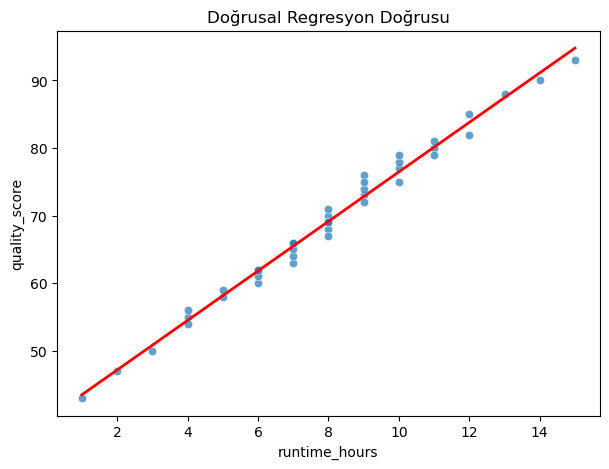

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

x_min = df["runtime_hours"].min()
x_max = df["runtime_hours"].max()
x_grid = np.linspace(x_min, x_max, 100).reshape(-1, 1)
y_grid = model.predict(x_grid)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="runtime_hours", y="quality_score", alpha=0.7)
plt.plot(x_grid, y_grid, color="red", linewidth=2)
plt.title("Doğrusal Regresyon Doğrusu")
plt.xlabel("runtime_hours")
plt.ylabel("quality_score")
plt.show()